> # Virtual Environment

In [1]:
'''
python -m venv environment\heart_disease_env
environment\heart_disease_env\Scripts\activate

# For jupyter notebook
ipython kernel install --user --name=heart_disease_env
pip freeze > requirements.txt
#pip install -r requirements.txt
'''

'\npython -m venv environment\\heart_disease_env\nenvironment\\heart_disease_env\\Scripts\x07ctivate\n\n# For jupyter notebook\nipython kernel install --user --name=heart_disease_env\npip freeze > requirements.txt\n#pip install -r requirements.txt\n'

In [68]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3]:
#pip install -r requirements.txt

> # Libraries

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import tensorflow as tf
from tensorflow.keras import models, layers, utils, backend as K
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import pathlib
import warnings
from IPython.core.display import display, HTML

df_file_path = tf.keras.utils.get_file("processed.cleveland.data", origin="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data", extract=True)

C:\Users\przem\AppData\Local\Temp\ipykernel_30656\527185743.py:15: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


> # Features

1. age - age in years

2. sex - sex (1 = male; 0 = female)

3. cp - chest pain type (1 = typical angina; 2 = atypical angina; 3 = non-anginal pain; 0 = asymptomatic)

4. trestbps - resting blood pressure (in mm Hg on admission to the hospital)

5. chol - serum cholestoral in mg/dl

6. fbs - fasting blood sugar > 120 mg/dl (1 = true; 0 = false)

7. restecg - resting electrocardiographic results (1 = normal; 2 = having ST-T wave abnormality; 0 = hypertrophy)

8. thalach - maximum heart rate achieved

9. exang - exercise induced angina (1 = yes; 0 = no)

10. oldpeak - ST depression induced by exercise relative to rest

11. slope - the slope of the peak exercise ST segment (2 = upsloping; 1 = flat; 0 = downsloping)

12. caa - number of major vessels (0-3) colored by flourosopy

13. thall - Thallium Stress Test (2 = normal; 1 = fixed defect; 3 = reversable defect)

14. output - the predicted attribute - heart disease diagnosis, 0 - patient is healthy, 1 - patient has the disease

> # Dataset

In [5]:
df_file_path = tf.keras.utils.get_file("processed.cleveland.data",
                                       origin="https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data", extract=True)


column_names = ['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output']

CATEGORICAL_FEATURE_KEYS = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'thall']
NUMERIC_FEATURE_KEYS = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'caa']


# missing values fillers
column_defaults=[np.nan for i in range(14)]
#column_defaults=[-999.for i in range(14)]
#column_defaults=[0. for i in range(14)]



In [6]:
def get_csv_data(file_path, column_defaults):
    tf_csv_ds = tf.data.experimental.make_csv_dataset(
        file_path,
        batch_size=12, 
        label_name='output',
        num_epochs=1,
        header=False,
        shuffle=True,
        na_value='?',
        column_names = column_names,
        column_defaults = column_defaults,
        #select_columns=select_columns,
        #record_defaults=column_defaults,
        ignore_errors=False)
    
    return tf_csv_ds


tf_csv_ds = get_csv_data(df_file_path, column_defaults)

for batch, output in tf_csv_ds.take(1):    
    for key, value in batch.items():
        print(f"{key:20s}: {value}")
    print()
    print(f"{'output':20s}: {output}")

age                 : [51. 64. 44. 44. 41. 60. 68. 47. 49. 56. 51. 43.]
sex                 : [1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 1.]
cp                  : [3. 4. 3. 3. 2. 4. 3. 4. 3. 4. 3. 4.]
trtbps              : [ 94. 128. 118. 140. 110. 158. 120. 112. 120. 134. 130. 150.]
chol                : [227. 263. 242. 235. 235. 305. 211. 204. 188. 409. 256. 247.]
fbs                 : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
restecg             : [0. 0. 0. 2. 0. 2. 2. 0. 0. 2. 2. 0.]
thalachh            : [154. 105. 149. 180. 153. 161. 115. 143. 139. 150. 149. 171.]
exng                : [1. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
oldpeak             : [0.  0.2 0.3 0.  0.  0.  1.5 0.1 2.  1.9 0.5 1.5]
slp                 : [1. 2. 2. 1. 1. 1. 2. 1. 2. 2. 1. 1.]
caa                 : [1. 1. 1. 0. 0. 0. 0. 0. 3. 2. 0. 0.]
thall               : [7. 7. 3. 3. 3. 3. 3. 3. 7. 7. 3. 3.]

output              : [0. 0. 0. 0. 0. 1. 0. 0. 3. 2. 0. 0.]


In [7]:
%%time
# ALL batches
display(list(tf_csv_ds.as_numpy_iterator()))

[(OrderedDict([('age',
                array([56., 51., 49., 62., 58., 35., 67., 57., 54., 62., 52., 60.],
                      dtype=float32)),
               ('sex',
                array([1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.], dtype=float32)),
               ('cp',
                array([2., 4., 4., 3., 3., 2., 3., 4., 4., 4., 2., 4.], dtype=float32)),
               ('trtbps',
                array([120., 140., 130., 130., 132., 122., 152., 152., 124., 140., 120.,
                       130.], dtype=float32)),
               ('chol',
                array([236., 298., 269., 231., 224., 192., 212., 274., 266., 394., 325.,
                       253.], dtype=float32)),
               ('fbs',
                array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32)),
               ('restecg',
                array([0., 0., 0., 0., 2., 0., 2., 0., 2., 2., 0., 0.], dtype=float32)),
               ('thalachh',
                array([178., 122., 163., 146., 173., 

CPU times: total: 93.8 ms
Wall time: 90.1 ms


> # 2. Data Analisis
Column names come from dataset description

In [8]:
def show_df(dataset, label_name=True):
    if label_name:
        batch, output = dataset.take(1).get_single_element()
        df = pd.DataFrame(batch)
        df['output'] = output
    else:
        batch = dataset.take(1).get_single_element() 
        df = pd.DataFrame(batch)
    return df

df = show_df(tf_csv_ds)
df

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,59.0,1.0,1.0,134.0,204.0,0.0,0.0,162.0,0.0,0.8,1.0,2.0,3.0,1.0
1,43.0,1.0,3.0,130.0,315.0,0.0,0.0,162.0,0.0,1.9,1.0,1.0,3.0,0.0
2,55.0,1.0,4.0,160.0,289.0,0.0,2.0,145.0,1.0,0.8,2.0,1.0,7.0,4.0
3,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2.0
4,48.0,1.0,2.0,130.0,245.0,0.0,2.0,180.0,0.0,0.2,2.0,0.0,3.0,0.0
5,66.0,1.0,4.0,120.0,302.0,0.0,2.0,151.0,0.0,0.4,2.0,0.0,3.0,0.0
6,53.0,1.0,4.0,142.0,226.0,0.0,2.0,111.0,1.0,0.0,1.0,0.0,7.0,0.0
7,58.0,1.0,4.0,114.0,318.0,0.0,1.0,140.0,0.0,4.4,3.0,3.0,6.0,4.0
8,43.0,0.0,4.0,132.0,341.0,1.0,2.0,136.0,1.0,3.0,2.0,0.0,7.0,2.0
9,48.0,1.0,4.0,130.0,256.0,1.0,2.0,150.0,1.0,0.0,1.0,2.0,7.0,3.0


> **batch info**

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       12 non-null     float32
 1   sex       12 non-null     float32
 2   cp        12 non-null     float32
 3   trtbps    12 non-null     float32
 4   chol      12 non-null     float32
 5   fbs       12 non-null     float32
 6   restecg   12 non-null     float32
 7   thalachh  12 non-null     float32
 8   exng      12 non-null     float32
 9   oldpeak   12 non-null     float32
 10  slp       12 non-null     float32
 11  caa       12 non-null     float32
 12  thall     12 non-null     float32
 13  output    12 non-null     float32
dtypes: float32(14)
memory usage: 804.0 bytes


In [10]:
df.describe()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
count,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000,12.000000
mean,55.916668,0.833333,3.083333,131.333328,271.083344,0.166667,1.416667,145.833328,0.416667,1.308333,1.666667,1.083333,4.916667,1.500000
std,9.472048,0.389249,1.240112,11.734435,42.003155,0.389249,0.900337,18.334435,0.514929,1.403540,0.651339,0.996205,2.020726,1.566699
min,43.000000,0.000000,1.000000,114.000000,204.000000,0.000000,0.000000,111.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,1.000000,2.000000,127.500000,242.250000,0.000000,0.750000,139.000000,0.000000,0.200000,1.000000,0.000000,3.000000,0.000000
50%,56.500000,1.000000,4.000000,130.000000,262.500000,0.000000,2.000000,146.000000,0.000000,0.800000,2.000000,1.000000,4.500000,1.500000
75%,61.500000,1.000000,4.000000,134.000000,305.250000,0.000000,2.000000,153.750000,1.000000,2.075000,2.000000,2.000000,7.000000,2.250000
max,74.000000,1.000000,4.000000,160.000000,341.000000,1.000000,2.000000,180.000000,1.000000,4.400000,3.000000,3.000000,7.000000,4.000000


> **1. Uniqueness**

In [11]:
# Displays a list of dataframes next to each other

def display_side_by_side(dfs:list, captions:list, tablespacing=5):
    output = ""
    for (caption, df) in zip(captions, dfs):
        output += df.style.set_table_attributes("style='display:inline'")._repr_html_()
        output += tablespacing * "\xa0"
    display(HTML(output))  


In [12]:
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

# returns a list with the number of unique values for a given label

def unique_csv(dataset, label):
    
    class_counts = pd.DataFrame()

    for batch, outputs in dataset:    
        
        # count classes
        if label == 'output':     
            for output in outputs:
                output = output.numpy()               
                if output not in class_counts:
                    class_counts[output] = [0]          
                class_counts[output] += 1
                
        # count features
        else:        
            for value in batch[label]:            
                value = value.numpy()
                if value not in class_counts:
                    class_counts[value] = [0]
                class_counts[value] += 1


    class_counts =  class_counts.reindex(sorted(class_counts.columns), axis=1)
    class_counts = class_counts.rename(index={class_counts.index.values[0]:label})

    
    return class_counts.T

# display(unique_csv(tf_csv_ds, 'caa'))
print("All records =", np.sum(unique_csv(tf_csv_ds, 'output')))


All records = output    303
dtype: int64


> **1.1 Uniqueness - Categorical data**

In [13]:
list_dfs = list()
for label in CATEGORICAL_FEATURE_KEYS: 
    list_dfs.append(unique_csv(tf_csv_ds, label))

display_side_by_side(list_dfs, CATEGORICAL_FEATURE_KEYS)

,sex
0,97
1,206
,cp
1,23
2,50
3,86
4,144
,fbs
0,258
1,45


> **1.2 Uniqueness - Numerical data**

In [14]:
list_dfs = list()
for label in NUMERIC_FEATURE_KEYS: 
    list_dfs.append(unique_csv(tf_csv_ds, label))
    
display_side_by_side(list_dfs, NUMERIC_FEATURE_KEYS)

,age
29,1
34,2
35,4
37,2
38,2
39,4
40,3
41,10
42,8
43,8


> **1.3 Uniqueness - the number of unique values**

In [15]:
%%time

# returns a list with the number of unique values for all features
def nunique_csv(dataset, labels):  
    
    zeros_dict = {col: [0] for col in labels}
    column_counts = pd.DataFrame(zeros_dict)    
    
    for label in labels:                
        unique = unique_csv(dataset, label)    
        column_counts.loc[0,label] = len(unique.index) #len(unique.columns) # if unique_csv() is not transposed
        
    column_counts = column_counts.rename(index={column_counts.index.values[0]:'nunique'})    
    return column_counts.T
    
nunique_csv(tf_csv_ds, column_names)

CPU times: total: 1.94 s
Wall time: 1.9 s


,nunique
age,41
sex,2
cp,4
trtbps,50
chol,152
fbs,2
restecg,3
thalachh,91
exng,2
oldpeak,40


> **2. Missing values**

In [16]:
# Returns numbers of missing values
def nan_values_csv(dataset, label):
    class_counts = pd.DataFrame()

    for batch, outputs in dataset:    
        
        # nans in classes
        if label == 'output':     
            for output in outputs:
                output = output.numpy()
                if np.isnan(output):
                    if output not in class_counts:
                        class_counts[output] = [0]            
                    class_counts[output] += 1
                
        # nans in features
        else:        
            for value in batch[label]:   
                value = value.numpy()
                if np.isnan(value):
                    if value not in class_counts:
                        class_counts[value] = [0]
                    class_counts[value] += 1

    if len(class_counts) > 0:
        class_counts =  class_counts.reindex(sorted(class_counts.columns), axis=1)
        class_counts = class_counts.rename(index={class_counts.index.values[0]:label})
    
    return class_counts.T

list_dfs = list()
for label in column_names: 
    list_dfs.append(nan_values_csv(tf_csv_ds, label))
    
display_side_by_side(list_dfs, column_names)

,caa
nan,5
,thall
nan,2


> **3. data transformation**

In [17]:
def change_nan_to_zero(element, output, labels):
    
    for column_name in labels:
        if column_name != 'output':
            element[column_name] = tf.where(tf.math.is_nan(element[column_name]), 0.0, element[column_name])
        else:
            output = tf.where(tf.math.is_nan(output), 0.0, output)
    
    return element, output

#tf_csv_ds = tf_csv_ds.map(lambda x, y: change_nan_to_zero(x, y, column_names), num_parallel_calls=tf.data.AUTOTUNE)

show_df(tf_csv_ds)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,0.0
1,67.0,1.0,4.0,120.0,237.0,0.0,0.0,71.0,0.0,1.0,2.0,0.0,3.0,2.0
2,62.0,1.0,4.0,120.0,267.0,0.0,0.0,99.0,1.0,1.8,2.0,2.0,7.0,1.0
3,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0.0
4,40.0,1.0,1.0,140.0,199.0,0.0,0.0,178.0,1.0,1.4,1.0,0.0,7.0,0.0
5,42.0,1.0,4.0,140.0,226.0,0.0,0.0,178.0,0.0,0.0,1.0,0.0,3.0,0.0
6,42.0,1.0,3.0,130.0,180.0,0.0,0.0,150.0,0.0,0.0,1.0,0.0,3.0,0.0
7,51.0,1.0,1.0,125.0,213.0,0.0,2.0,125.0,1.0,1.4,1.0,1.0,3.0,0.0
8,61.0,0.0,4.0,145.0,307.0,0.0,2.0,146.0,1.0,1.0,2.0,0.0,7.0,1.0
9,41.0,1.0,3.0,112.0,250.0,0.0,0.0,179.0,0.0,0.0,1.0,0.0,3.0,0.0


In [18]:
# Function that changes column type from float to int
def change_type_to_int(element, output, labels):

    for column_name in labels:
        if column_name == 'output':
            output = tf.cast(output, tf.int32)
        elif column_name != 'oldpeak':
            element[column_name] = tf.cast(element[column_name], tf.int32)
            
    return element, output

# Apply the transformation to the dataset
tf_csv_ds = tf_csv_ds.map(lambda x, y: change_type_to_int(x, y, ['output']), num_parallel_calls=tf.data.AUTOTUNE)

show_df(tf_csv_ds)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,54.0,1.0,4.0,122.0,286.0,0.0,2.0,116.0,1.0,3.2,2.0,2.0,3.0,3
1,64.0,1.0,3.0,140.0,335.0,0.0,0.0,158.0,0.0,0.0,1.0,0.0,3.0,1
2,39.0,0.0,3.0,94.0,199.0,0.0,0.0,179.0,0.0,0.0,1.0,0.0,3.0,0
3,59.0,1.0,4.0,140.0,177.0,0.0,0.0,162.0,1.0,0.0,1.0,1.0,7.0,2
4,69.0,1.0,3.0,140.0,254.0,0.0,2.0,146.0,0.0,2.0,2.0,3.0,7.0,2
5,67.0,0.0,3.0,152.0,277.0,0.0,0.0,172.0,0.0,0.0,1.0,1.0,3.0,0
6,47.0,1.0,3.0,130.0,253.0,0.0,0.0,179.0,0.0,0.0,1.0,0.0,3.0,0
7,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
8,58.0,1.0,4.0,128.0,259.0,0.0,2.0,130.0,1.0,3.0,2.0,2.0,7.0,3
9,42.0,0.0,4.0,102.0,265.0,0.0,2.0,122.0,0.0,0.6,2.0,0.0,3.0,0


In [19]:
# Function that changes output with values greater than 1 to 1
def binary_output(element, output):
    output = tf.where(output > 0, 1, output)
    return element, output

# Apply the transformation to the dataset
tf_csv_ds = tf_csv_ds.map(binary_output, num_parallel_calls=tf.data.AUTOTUNE)

show_df(tf_csv_ds)

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,48.0,1.0,4.0,122.0,222.0,0.0,2.0,186.0,0.0,0.0,1.0,0.0,3.0,0
1,63.0,0.0,2.0,140.0,195.0,0.0,0.0,179.0,0.0,0.0,1.0,2.0,3.0,0
2,63.0,1.0,4.0,140.0,187.0,0.0,2.0,144.0,1.0,4.0,1.0,2.0,7.0,1
3,44.0,1.0,2.0,120.0,263.0,0.0,0.0,173.0,0.0,0.0,1.0,0.0,7.0,0
4,58.0,0.0,4.0,100.0,248.0,0.0,2.0,122.0,0.0,1.0,2.0,0.0,3.0,0
5,58.0,1.0,3.0,132.0,224.0,0.0,2.0,173.0,0.0,3.2,1.0,2.0,7.0,1
6,44.0,1.0,2.0,120.0,220.0,0.0,0.0,170.0,0.0,0.0,1.0,0.0,3.0,0
7,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,NaN,7.0,0
8,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,1
9,60.0,1.0,4.0,117.0,230.0,1.0,0.0,160.0,1.0,1.4,1.0,2.0,7.0,1


> # 3. Graphs

In [20]:
def distribution(label):
    return (unique_csv(tf_csv_ds, label).index.values, unique_csv(tf_csv_ds, label).values.reshape(-1))

In [21]:
distribution('age')

(array([29, 34, 35, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 74, 76, 77], dtype=int64),
 array([ 1,  2,  4,  2,  2,  4,  3, 10,  8,  8, 11,  8,  7,  5,  7,  5,  7,
        12, 13,  8, 16,  8, 11, 17, 19, 14, 12,  8, 11,  9, 10,  8,  7,  9,
         4,  3,  4,  3,  1,  1,  1], dtype=int64))

Outputs: [0 1] 
counts: [164 139]


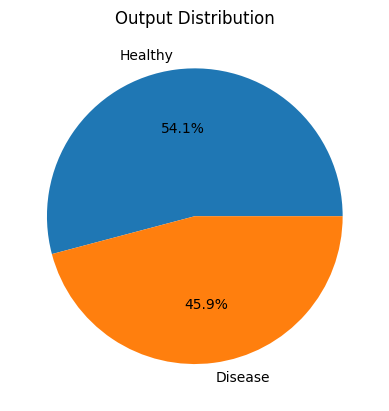

In [22]:
values, counts = distribution('output')
print('Outputs:', values, '\ncounts:', counts)

labels=['Healthy', 'Disease']

plt.pie(counts,
        labels=labels, autopct='%1.1f%%')
plt.title('Output Distribution')
plt.show()

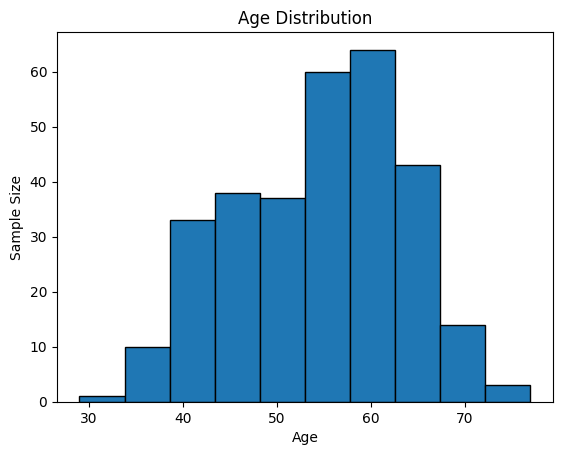

Outputs: [29 34 35 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57
 58 59 60 61 62 63 64 65 66 67 68 69 70 71 74 76 77] 
counts: [ 1  2  4  2  2  4  3 10  8  8 11  8  7  5  7  5  7 12 13  8 16  8 11 17
 19 14 12  8 11  9 10  8  7  9  4  3  4  3  1  1  1]


In [23]:
values, counts = distribution('age')

plt.hist(values, weights=counts, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Sample Size')
plt.show()

print('Outputs:', values, '\ncounts:', counts)

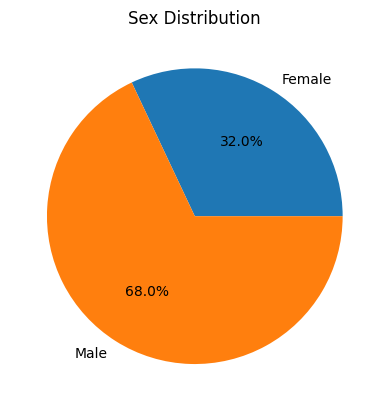

genders [0 1] 
genders: ['Female', 'Male'] 
counts: [ 97 206]


In [24]:
values, counts = distribution('sex')

labels=['Female', 'Male']
plt.pie(counts, labels=labels,  autopct='%1.1f%%')
plt.title('Sex Distribution')
plt.show()

print('genders', values, '\ngenders:', labels, '\ncounts:', counts)

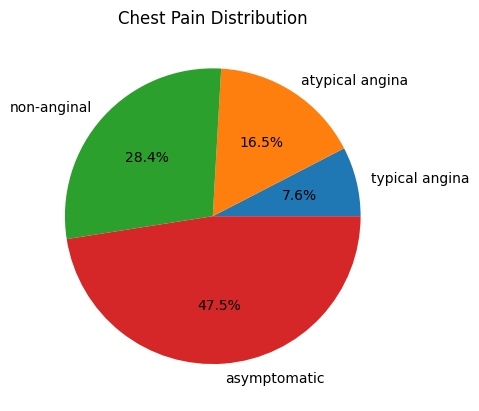

chest pain: [1 2 3 4] 
counts: [ 23  50  86 144]
1 = typical angina 
2 = atypical angina 
3 = non-anginal pain 
0 = asymptomatic


In [25]:
values, counts = distribution('cp') 
labels=['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic']
plt.pie(counts, labels=['typical angina', 'atypical angina', 'non-anginal', 'asymptomatic'],  autopct='%1.1f%%')
plt.title('Chest Pain Distribution')
plt.show()

print('chest pain:', values, '\ncounts:', counts)
print('1 = typical angina \n2 = atypical angina \n3 = non-anginal pain \n0 = asymptomatic')

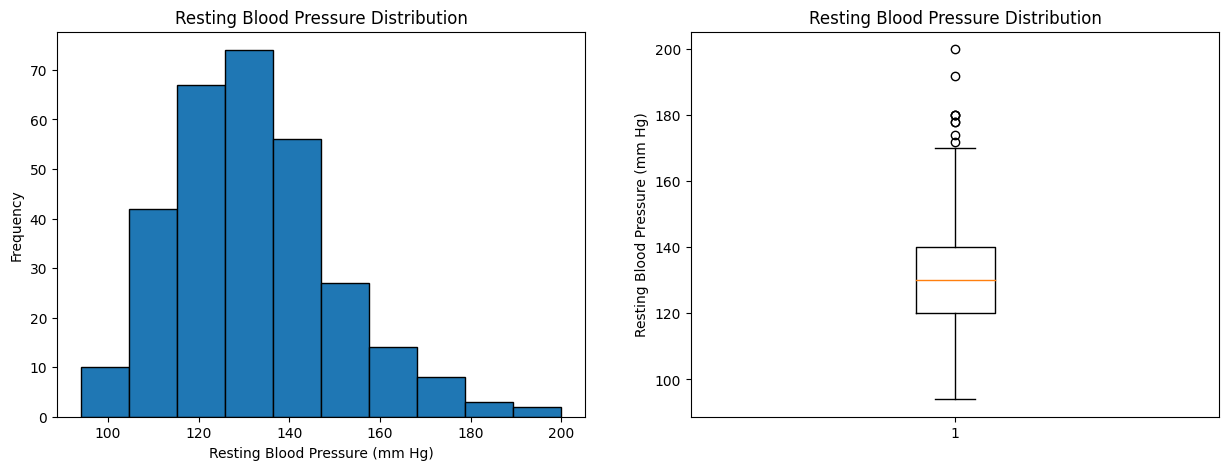

In [26]:
values, counts = distribution('trtbps') 

data = []
for value, count in zip(values, counts):
    data.extend([value] * count)

figure, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].hist(values, weights=counts, edgecolor='black')
axis[0].set_title('Resting Blood Pressure Distribution')
axis[0].set_xlabel('Resting Blood Pressure (mm Hg)')
axis[0].set_ylabel('Frequency')

axis[1].boxplot(data)
axis[1].set_title('Resting Blood Pressure Distribution')
axis[1].set_ylabel('Resting Blood Pressure (mm Hg)')
plt.show()

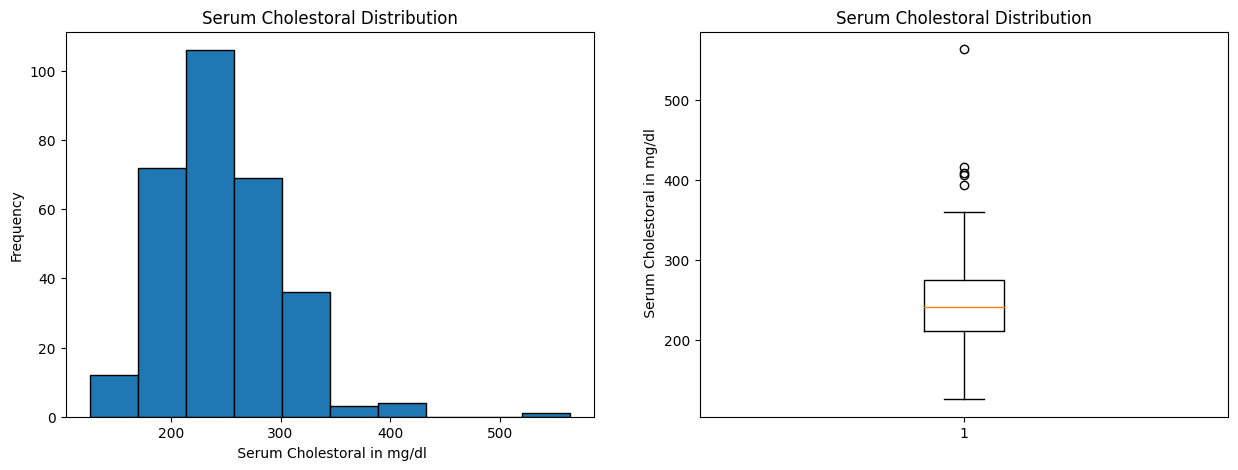

In [27]:
values, counts = distribution('chol') 

data = []
for value, count in zip(values, counts):
    data.extend([value] * count)


figure, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].hist(values, weights=counts, edgecolor='black')
axis[0].set_title('Serum Cholestoral Distribution')
axis[0].set_xlabel(' Serum Cholestoral in mg/dl')
axis[0].set_ylabel('Frequency')

axis[1].boxplot(data)
axis[1].set_title('Serum Cholestoral Distribution')
axis[1].set_ylabel(' Serum Cholestoral in mg/dl')
plt.show()

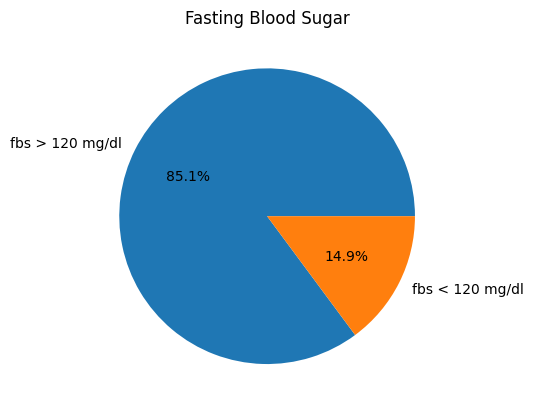

Fasting Blood Sugar [0 1] 
counts: [258  45]
1 = fbs > 120 mg/dl 
0 = fbs < 120 mg/dl


In [28]:
values, counts = distribution('fbs') 

plt.pie(counts, labels=['fbs > 120 mg/dl', 'fbs < 120 mg/dl'],  autopct='%1.1f%%')
plt.title('Fasting Blood Sugar')
plt.show()

print('Fasting Blood Sugar', values, '\ncounts:', counts)
print('1 = fbs > 120 mg/dl \n0 = fbs < 120 mg/dl')

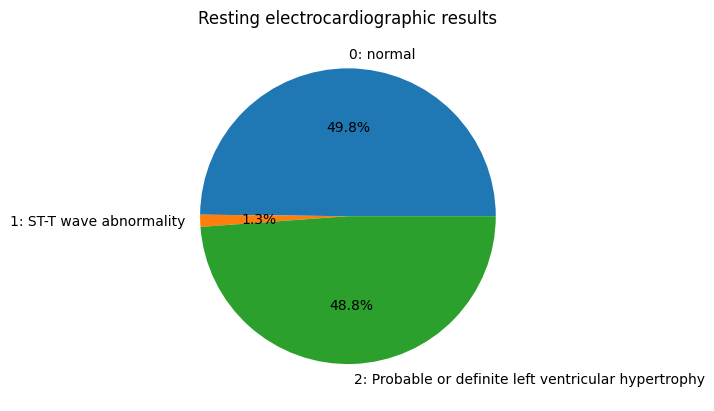

Resting electrocardiographic results, counts: [0 1 2] [151   4 148]
Value 0: normal 
Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) 
Value 2: showing probable or definite left ventricular hypertrophy by Estes criteria


In [29]:
values, counts = distribution('restecg') 

plt.pie(counts, labels=['0: normal', '1: ST-T wave abnormality', '2: Probable or definite left ventricular hypertrophy'],  autopct='%1.1f%%')
plt.title('Resting electrocardiographic results')
plt.show()

print('Resting electrocardiographic results, counts:', values, counts)
print('Value 0: normal \nValue 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV) \nValue 2: showing probable or definite left ventricular hypertrophy by Estes criteria')

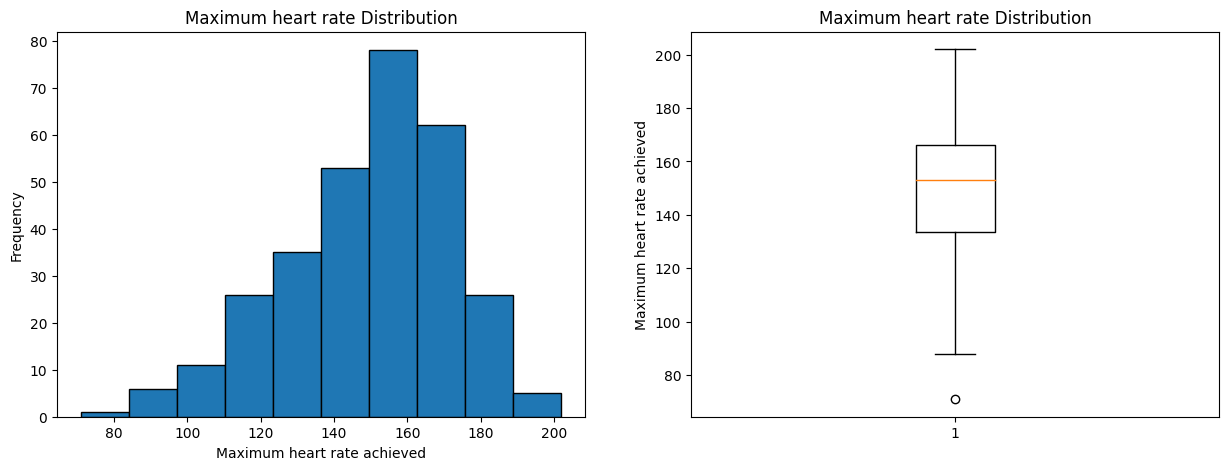

In [30]:
values, counts = distribution('thalachh') 

data = []
for value, count in zip(values, counts):
    data.extend([value] * count)


figure, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].hist(values, weights=counts, edgecolor='black')
axis[0].set_title('Maximum heart rate Distribution')
axis[0].set_xlabel('Maximum heart rate achieved')
axis[0].set_ylabel('Frequency')

axis[1].boxplot(data)
axis[1].set_title('Maximum heart rate Distribution')
axis[1].set_ylabel('Maximum heart rate achieved')
plt.show()

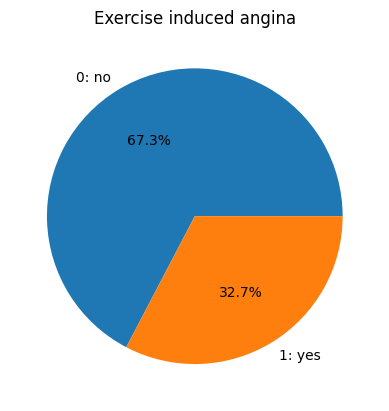

Exercise induced angina (1 = yes; 0 = no), counts: [0 1] [204  99]


In [31]:
values, counts = distribution('exng') 

plt.pie(counts, labels=['0: no', '1: yes'],  autopct='%1.1f%%')
plt.title('Exercise induced angina')
plt.show()

print('Exercise induced angina (1 = yes; 0 = no), counts:', values, counts)

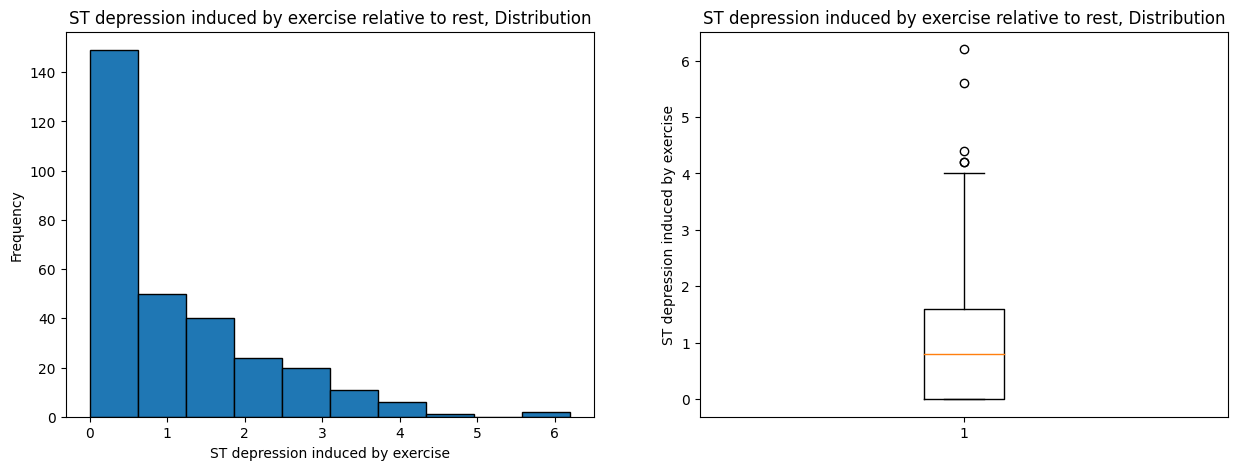

In [32]:
values, counts = distribution('oldpeak') 

data = []
for value, count in zip(values, counts):
    data.extend([value] * count)


figure, axis = plt.subplots(1, 2, figsize=(15, 5))
axis[0].hist(values, weights=counts, edgecolor='black')
axis[0].set_title('ST depression induced by exercise relative to rest, Distribution')
axis[0].set_xlabel('ST depression induced by exercise')
axis[0].set_ylabel('Frequency')

axis[1].boxplot(data)
axis[1].set_title('ST depression induced by exercise relative to rest, Distribution')
axis[1].set_ylabel('ST depression induced by exercise')
plt.show()

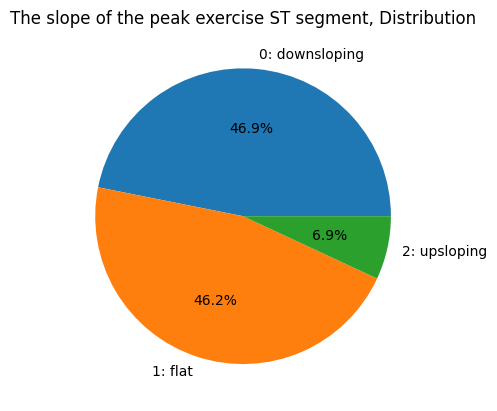

The slope of the peak exercise ST segment (2 = upsloping; 1 = flat; 0 = downsloping), counts: [1 2 3] [142 140  21]


In [33]:
values, counts = distribution('slp') 

plt.pie(counts, labels=['0: downsloping', '1: flat', '2: upsloping',],  autopct='%1.1f%%')
plt.title('The slope of the peak exercise ST segment, Distribution')
plt.show()

print('The slope of the peak exercise ST segment (2 = upsloping; 1 = flat; 0 = downsloping), counts:', values, counts)

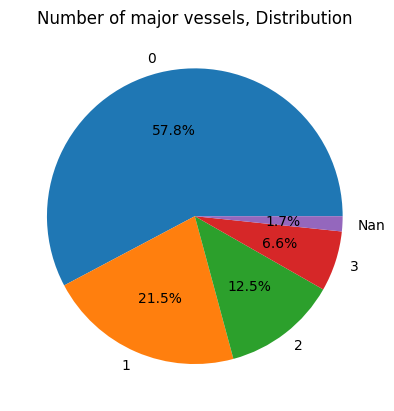

number of major vessels (0-3) colored by flourosopy, counts: [ 0.  1.  2.  3. nan] [175  65  38  20   5]


In [34]:
values, counts = distribution('caa') 

values, counts
plt.pie(counts, labels=['0', '1', '2', '3', 'Nan'],  autopct='%1.1f%%')
plt.title('Number of major vessels, Distribution')
plt.show()

print('number of major vessels (0-3) colored by flourosopy, counts:', values, counts)

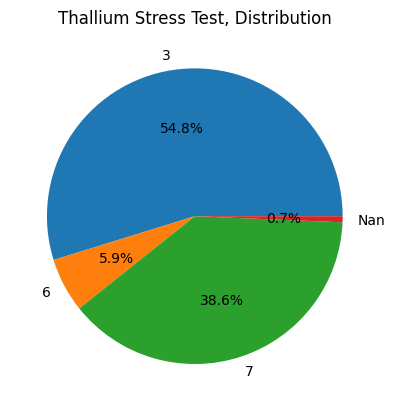

Thallium Stress Test (3,6,7):
3 = normal
6 = fixed defect
7 = reversable defect


In [35]:
values, counts = distribution('thall') 

plt.pie(counts, labels=['3','6','7', 'Nan'],  autopct='%1.1f%%')
plt.title('Thallium Stress Test, Distribution')
plt.show()

#print('Thallium Stress Test (1-3): 2 = normal; 1 = fixed defect; 3 = reversable defect, counts:', values, counts)
print('Thallium Stress Test (3,6,7):')
print('3 = normal')
print('6 = fixed defect')
print('7 = reversable defect')

> # **Compare Disease/Healthy Ratio**

In [36]:
df = pd.read_csv("./UCI_Heart_Disease/processed.cleveland.data", header=None)
df.columns = column_names

for column in df.columns:
    for j in range(len(df)):
        df[column] = pd.to_numeric(df[column], downcast="integer", errors='coerce')

df_fig = df.copy()
df_fig.loc[:,'output'] = df_fig['output'].where(df_fig['output'] < 1, 1)
df_fig

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,1
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,1
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1


C:\Users\przem\AppData\Local\Temp\ipykernel_30656\264946639.py:1: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use("seaborn")


<Figure size 800x550 with 0 Axes>

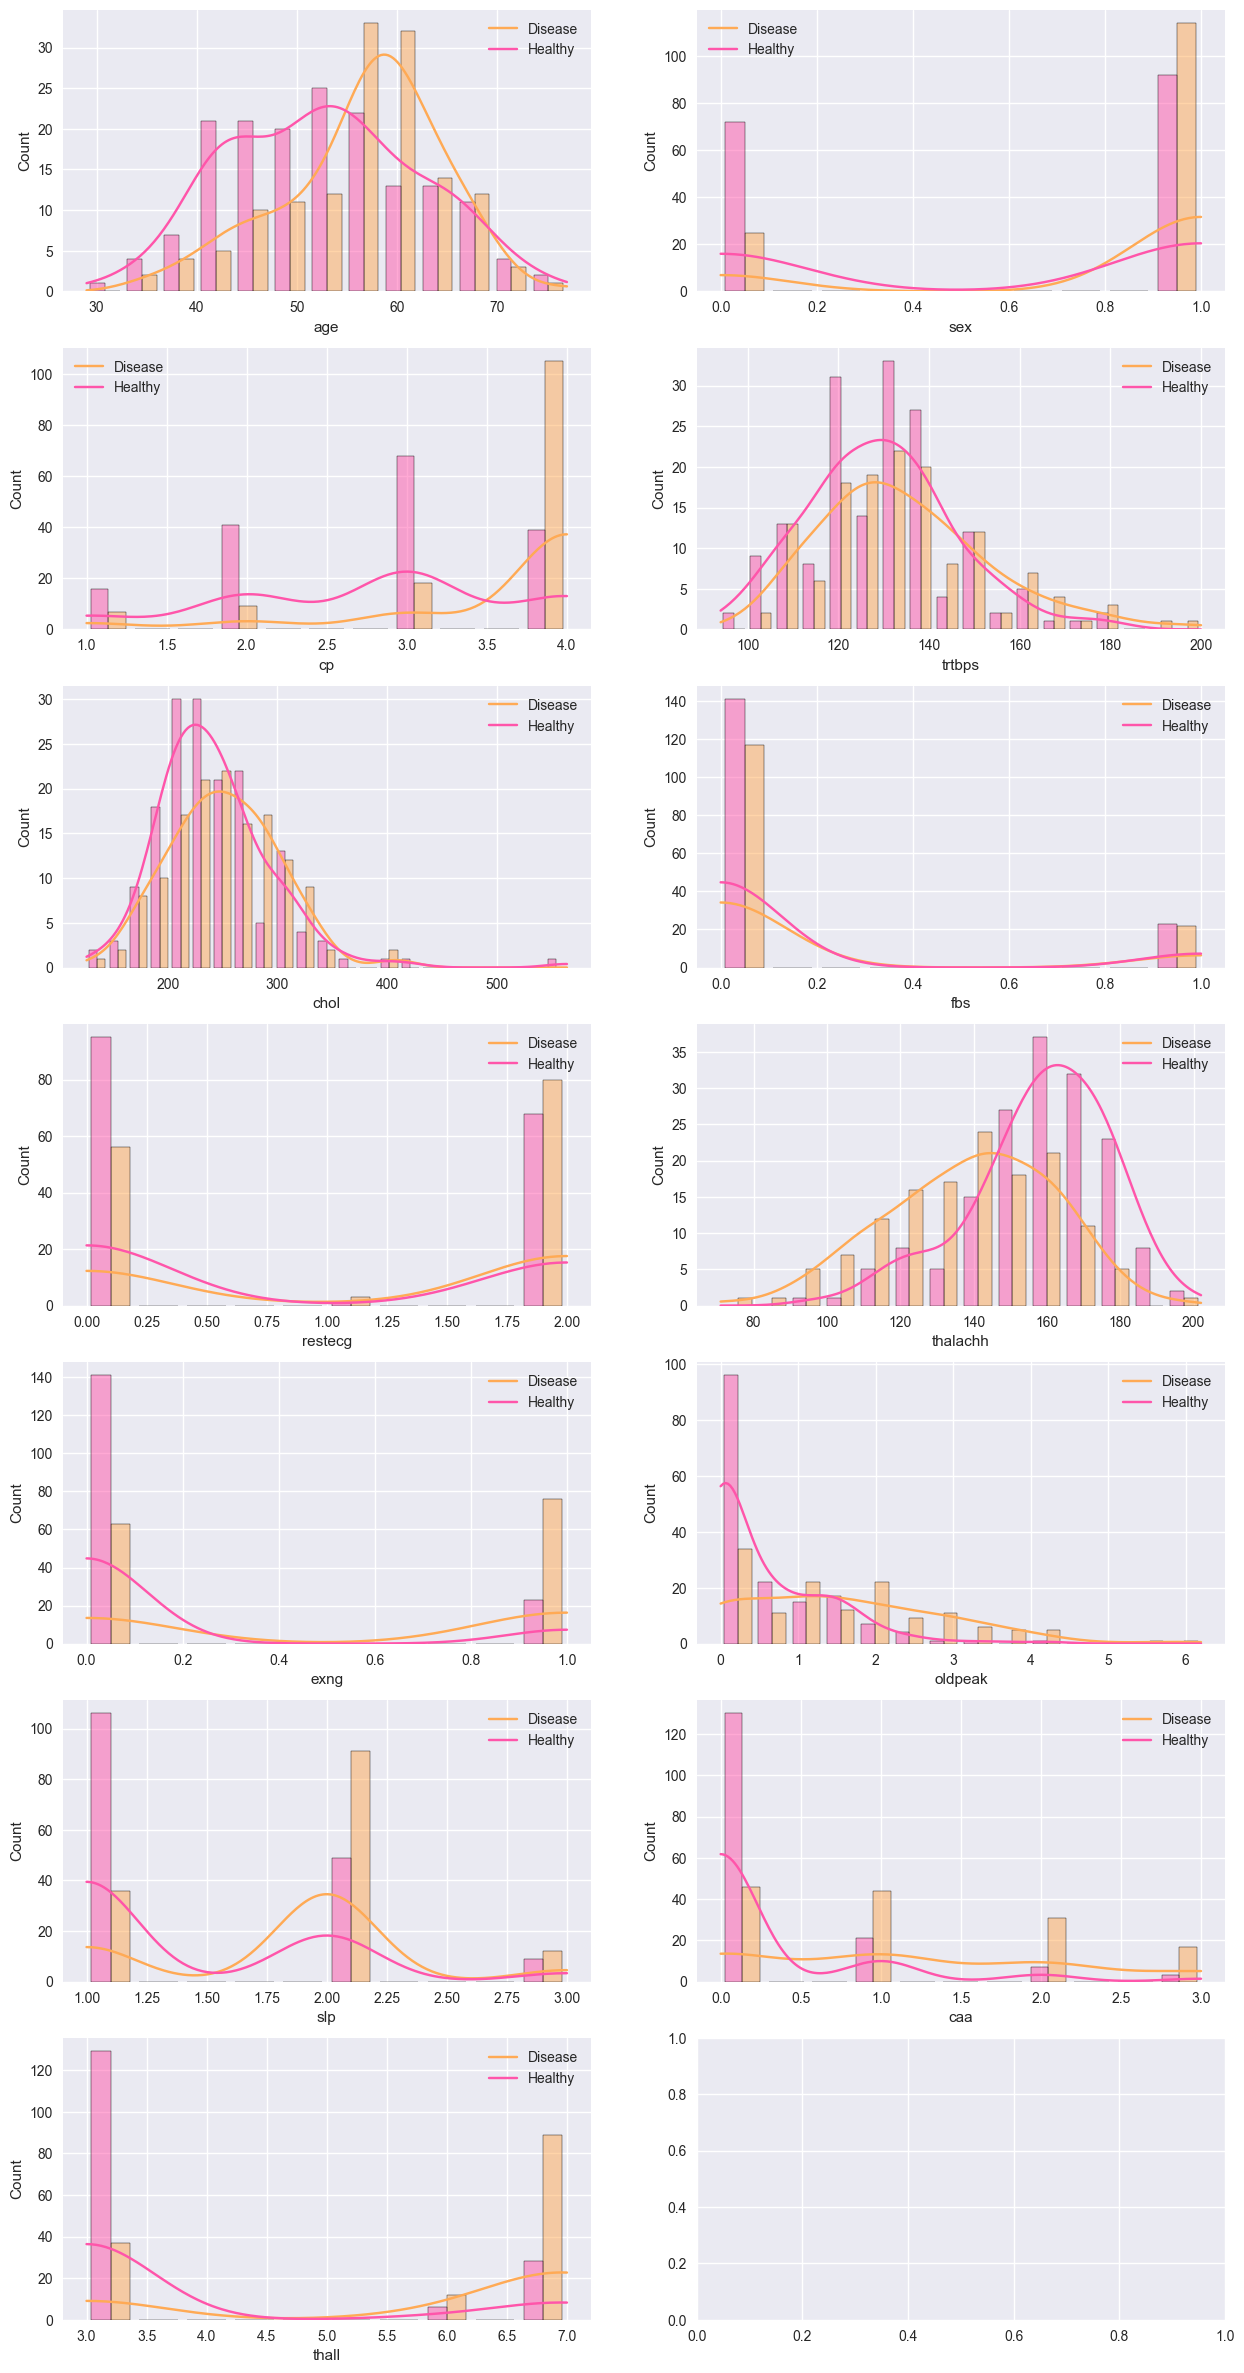

In [37]:
plt.style.use("seaborn")
plt.subplots_adjust(hspace=0.3)
color = 'spring'
fig, axs = plt.subplots(7, 2, figsize=(15,30))
i=1
for feature in df.columns:
    if feature not in ['output']:
        plt.subplot(7,2,i)
        sns.histplot(data=df_fig, x=feature, kde=True, palette=color, hue='output', multiple="dodge", shrink=.8)   
        plt.legend(labels=['Disease', 'Healthy'])
        i+=1
plt.show()

> # **2.b k-NearestNeighbours**

In [38]:
from sklearn.neighbors import KNeighborsClassifier

df = df.dropna()
df[['caa','thall']] = df[['caa','thall']].astype(int)

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,:-1], df['output'], test_size=0.2, random_state=19)

kNN_acc = []

for k in range(1, 11):
    kNN_model = KNeighborsClassifier(n_neighbors=k)
    kNN_model.fit(X_train, y_train)
    acc = kNN_model.score(X_test, y_test)
    kNN_acc.append(acc)
    
for k in range(1, 11):
    print('k =', k,'-', np.round(kNN_acc[k-1], 2), '%')

k = 1 - 0.38 %
k = 2 - 0.5 %
k = 3 - 0.48 %
k = 4 - 0.57 %
k = 5 - 0.53 %
k = 6 - 0.55 %
k = 7 - 0.58 %
k = 8 - 0.58 %
k = 9 - 0.55 %
k = 10 - 0.57 %


> # **2.d Correlations**

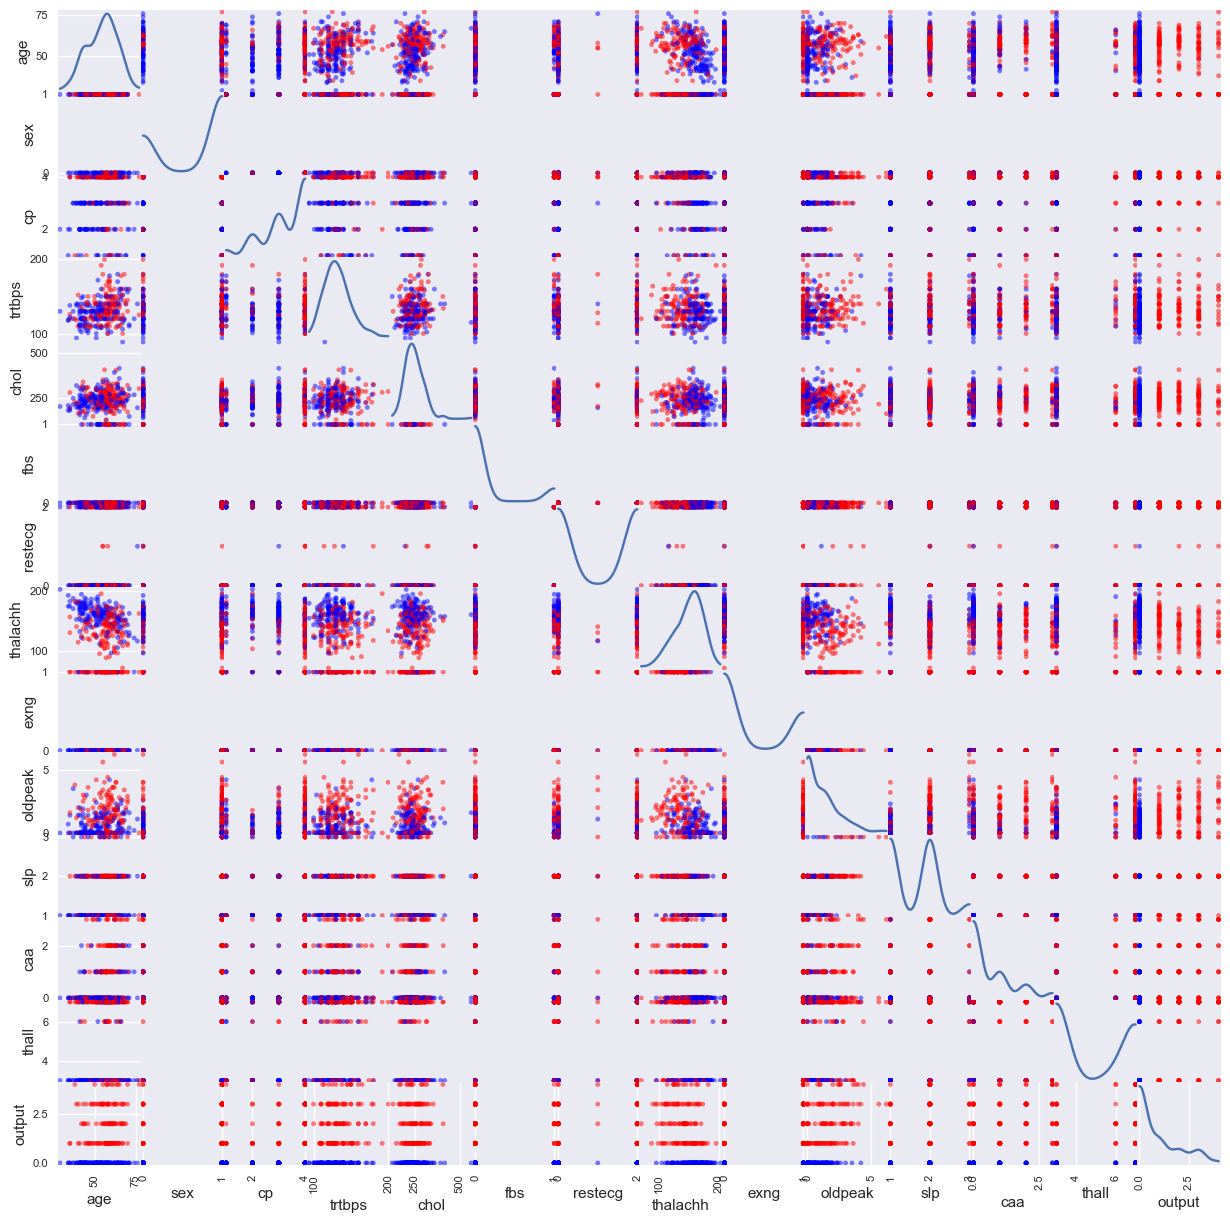

In [39]:
colors = []
for i in range(len(df)):
    if df.iloc[i, -1] > 0:
        colors.append('r') # red - disease
    else:
        colors.append('b') # blue - healthy
        
        
scatter_matrix(df,               
                figsize=(15,15),
                diagonal='kde',
               c=colors
              );


> **Only numerical data**

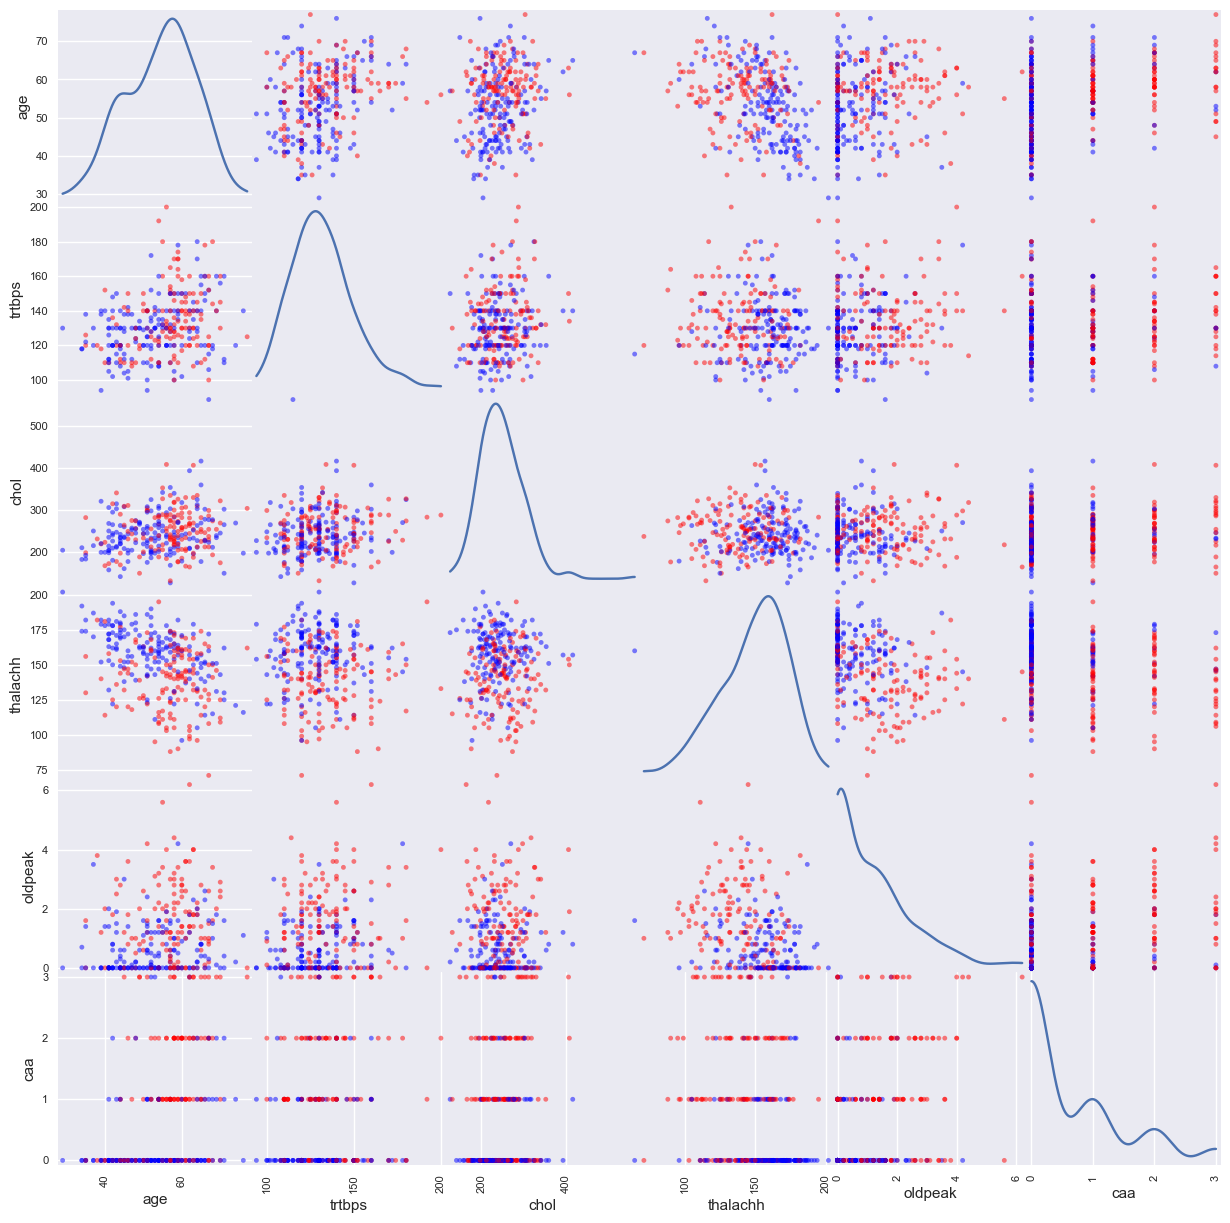

In [40]:
scatter_matrix(df[NUMERIC_FEATURE_KEYS],               
                figsize=(15,15),
                diagonal='kde',
               c=colors
              );

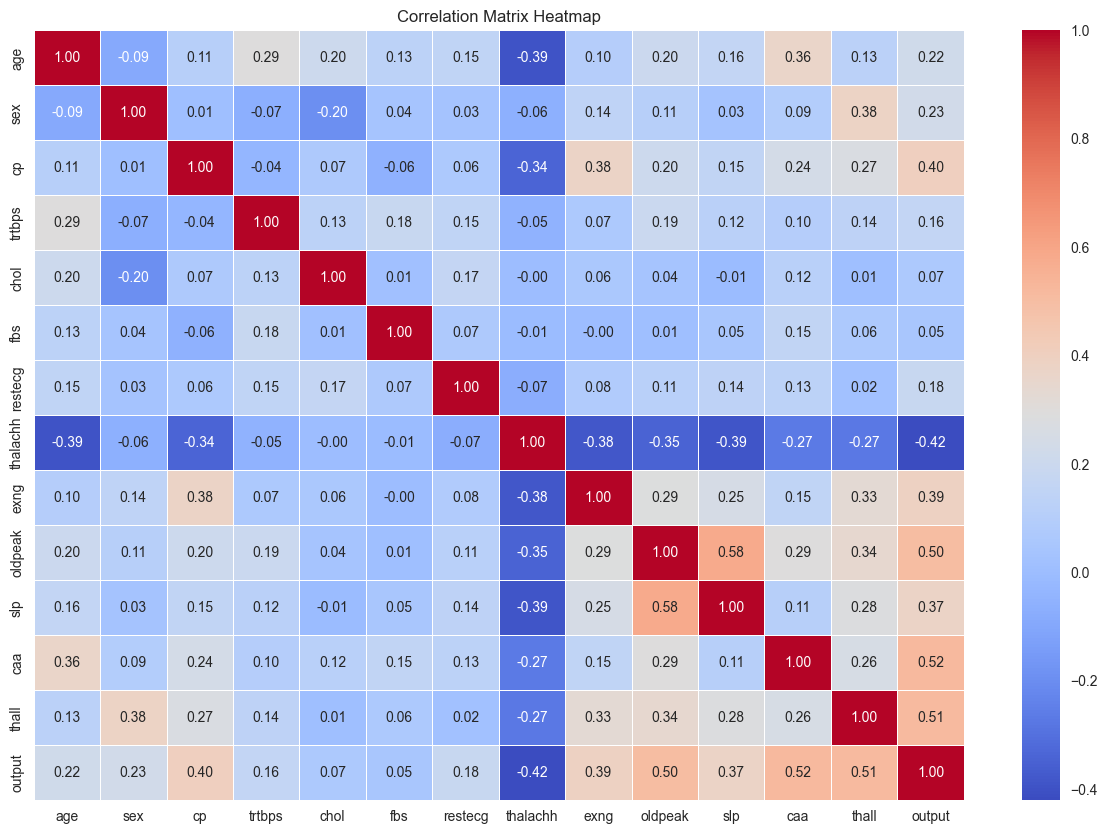

In [41]:
#Correlation matrix
correlation_matrix = df.corr()

plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title("Correlation Matrix Heatmap")
plt.show()

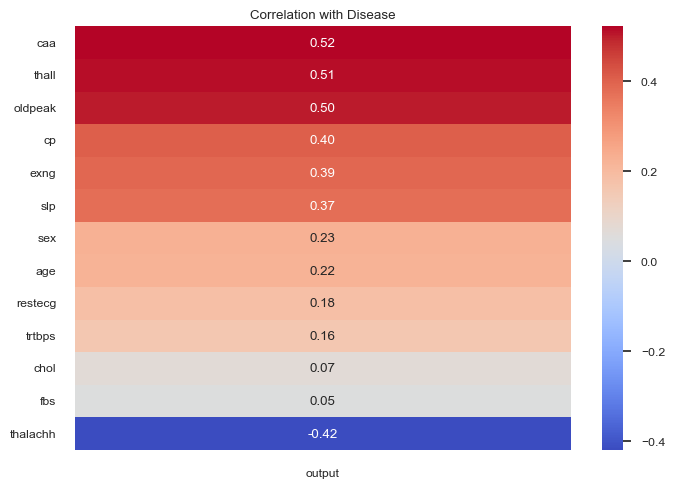

In [42]:
# Correlation to output
corr = df.corr()
target_corr = corr['output'].drop('output')

# sort values
target_corr_sorted = target_corr.sort_values(ascending=False)

sns.set(font_scale=0.8)
sns.set_style("white")
sns.set_palette("PuBuGn_d")
sns.heatmap(target_corr_sorted.to_frame(), cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation with Disease')
plt.show()

> # **Feature Engineering**

In [43]:
# record_defaults=[0. for i in range(14)] #np.nan
# tf_csv_ds = tf.data.experimental.make_csv_dataset(
#     df_file_path,
#     batch_size=12, 
#     label_name='output',
#     num_epochs=1,
#     header=False,
#     shuffle=False,
#     na_value='?',
#     column_names= column_names,
#     column_defaults=record_defaults,
#     #select_columns=select_columns,
#     #record_defaults=column_defaults,
#     ignore_errors=False)

column_defaults=[-999.for i in range(14)]
tf_csv_ds = get_csv_data(df_file_path, column_defaults)

for batch, output in tf_csv_ds.take(1):    
    for key, value in batch.items():
        print(f"{key:20s}: {value}")
    print()
    print(f"{'output':20s}: {output}")

age                 : [77. 63. 56. 59. 41. 45. 46. 65. 58. 62. 44. 57.]
sex                 : [1. 0. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1.]
cp                  : [4. 3. 3. 3. 3. 4. 2. 4. 3. 3. 2. 3.]
trtbps              : [125. 135. 130. 150. 130. 138. 105. 110. 112. 130. 130. 150.]
chol                : [304. 252. 256. 212. 214. 236. 204. 248. 230. 231. 219. 168.]
fbs                 : [0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
restecg             : [2. 2. 2. 0. 2. 2. 0. 2. 2. 0. 2. 0.]
thalachh            : [162. 172. 142. 157. 168. 152. 172. 158. 165. 146. 188. 174.]
exng                : [1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
oldpeak             : [0.  0.  0.6 1.6 2.  0.2 0.  0.6 2.5 1.8 0.  1.6]
slp                 : [1. 1. 2. 1. 2. 2. 1. 1. 2. 2. 1. 1.]
caa                 : [3. 0. 1. 0. 0. 0. 0. 2. 1. 3. 0. 0.]
thall               : [3. 3. 6. 3. 3. 3. 3. 6. 7. 7. 3. 3.]

output              : [4. 0. 2. 0. 0. 0. 0. 1. 4. 0. 0. 0.]


<>:16: SyntaxWarning: invalid decimal literal
<>:16: SyntaxWarning: invalid decimal literal
C:\Users\przem\AppData\Local\Temp\ipykernel_30656\3991017790.py:16: SyntaxWarning: invalid decimal literal
  column_defaults=[-999.for i in range(14)]


In [44]:
CATEGORICAL_FEATURE_KEYS = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'thall']
NUMERIC_FEATURE_KEYS = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak', 'caa']

df = show_df(tf_csv_ds)
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,51.0,1.0,3.0,110.0,175.0,0.0,0.0,123.0,0.0,0.6,1.0,0.0,3.0,0.0
1,56.0,1.0,4.0,130.0,283.0,1.0,2.0,103.0,1.0,1.6,3.0,0.0,7.0,2.0
2,64.0,1.0,1.0,170.0,227.0,0.0,2.0,155.0,0.0,0.6,2.0,0.0,7.0,0.0
3,69.0,0.0,1.0,140.0,239.0,0.0,0.0,151.0,0.0,1.8,1.0,2.0,3.0,0.0
4,41.0,0.0,3.0,112.0,268.0,0.0,2.0,172.0,1.0,0.0,1.0,0.0,3.0,0.0


> **Preprocessing**

In [45]:

# if the column_defaults's missing values are not set as NaN then does nothing
tf_csv_ds = tf_csv_ds.map(lambda x, y: change_nan_to_zero(x, y, column_names), num_parallel_calls=tf.data.AUTOTUNE)

tf_csv_ds = tf_csv_ds.map(lambda x, y: change_type_to_int(x, y, CATEGORICAL_FEATURE_KEYS + ['output']), num_parallel_calls=tf.data.AUTOTUNE)
tf_csv_ds = tf_csv_ds.map(binary_output, num_parallel_calls=tf.data.AUTOTUNE)
show_df(tf_csv_ds).head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,61.0,1,4,140.0,207.0,0,2,138.0,1,1.9,1,1.0,7,1
1,39.0,1,4,118.0,219.0,0,0,140.0,0,1.2,2,0.0,7,1
2,47.0,1,3,138.0,257.0,0,2,156.0,0,0.0,1,0.0,3,0
3,44.0,1,2,130.0,219.0,0,2,188.0,0,0.0,1,0.0,3,0
4,54.0,1,4,110.0,239.0,0,0,126.0,1,2.8,2,1.0,7,1


> # **Spliting & Oversampling data**

In [46]:
N_VALIDATION = 4
N_TEST = 4
N_TRAIN= 17

validate_ds = tf_csv_ds.take(N_VALIDATION).cache().prefetch(tf.data.AUTOTUNE).repeat()
train_ds = tf_csv_ds.skip(N_VALIDATION).take(N_TRAIN).cache().prefetch(tf.data.AUTOTUNE).repeat()
test_ds = tf_csv_ds.skip(N_VALIDATION+N_TRAIN).take(N_TEST).cache().prefetch(tf.data.AUTOTUNE).repeat(1)

In [47]:
# Display testing batches
display(test_ds.batch(N_TEST).take(1).get_single_element())

(OrderedDict([('age',
               <tf.Tensor: shape=(4, 12), dtype=float32, numpy=
               array([[29., 48., 37., 47., 65., 65., 60., 44., 45., 53., 48., 51.],
                      [43., 41., 54., 63., 58., 57., 52., 64., 41., 70., 50., 57.],
                      [77., 69., 70., 58., 55., 52., 51., 41., 38., 43., 39., 55.],
                      [53., 48., 54., 58., 48., 51., 50., 53., 63., 57., 51., 52.]],
                     dtype=float32)>),
              ('sex',
               <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
               array([[1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0],
                      [1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1],
                      [1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1],
                      [0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1]])>),
              ('cp',
               <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
               array([[2, 4, 3, 3, 3, 4, 3, 3, 4, 4, 4, 4],
                      [4, 2, 3, 3, 3, 4, 2, 4, 2, 4, 3, 2],
       

In [48]:
# Display validate batches
display(validate_ds.batch(N_VALIDATION).take(1).get_single_element())

(OrderedDict([('age',
               <tf.Tensor: shape=(4, 12), dtype=float32, numpy=
               array([[54., 44., 47., 38., 59., 53., 60., 45., 67., 58., 46., 43.],
                      [52., 71., 51., 44., 61., 55., 63., 57., 63., 51., 64., 54.],
                      [42., 50., 44., 44., 56., 58., 57., 46., 40., 64., 48., 65.],
                      [62., 35., 45., 61., 42., 58., 44., 55., 63., 55., 60., 46.]],
                     dtype=float32)>),
              ('sex',
               <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
               array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1],
                      [1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1],
                      [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1],
                      [0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1]])>),
              ('cp',
               <tf.Tensor: shape=(4, 12), dtype=int32, numpy=
               array([[2, 4, 3, 1, 2, 4, 4, 1, 4, 2, 4, 4],
                      [4, 2, 3, 2, 4, 4, 4, 2, 3, 3, 4, 2],
       

In [49]:
# Display training batches
display(train_ds.batch(N_TRAIN).take(1).get_single_element())

(OrderedDict([('age',
               <tf.Tensor: shape=(17, 12), dtype=float32, numpy=
               array([[57., 64., 66., 54., 61., 67., 52., 43., 58., 41., 64., 62.],
                      [53., 66., 63., 63., 70., 70., 43., 46., 58., 44., 35., 59.],
                      [57., 40., 54., 41., 64., 56., 58., 71., 65., 44., 37., 62.],
                      [54., 64., 44., 52., 60., 46., 51., 59., 48., 57., 54., 53.],
                      [59., 42., 40., 57., 60., 43., 68., 55., 60., 51., 64., 58.],
                      [61., 41., 68., 54., 49., 43., 44., 43., 52., 41., 71., 43.],
                      [56., 50., 74., 50., 64., 42., 61., 53., 59., 62., 57., 58.],
                      [58., 47., 51., 35., 42., 57., 44., 60., 69., 64., 62., 62.],
                      [56., 58., 56., 59., 66., 67., 56., 29., 47., 58., 60., 56.],
                      [44., 59., 44., 46., 61., 45., 54., 49., 60., 50., 51., 44.],
                      [52., 65., 62., 58., 54., 54., 52., 49., 44., 54., 

> # **Layers**

In [50]:

def get_normalization_layer(name, dataset):
    # Create a Normalization layer for the feature.
    normalizer = layers.Normalization(axis=None)

    # Prepare a Dataset that only yields the feature.
    feature_ds = dataset.map(lambda x, y: x[name])

    # Learn the statistics of the data.
    normalizer.adapt(feature_ds)
    
    return normalizer


#Test
test_label = df['age']
layer = get_normalization_layer('age', tf_csv_ds)
layer(test_label)

<tf.Tensor: shape=(12,), dtype=float32, numpy=
array([-0.38109884,  0.17299555,  1.0595466 ,  1.613641  , -1.4892876 ,
       -0.49191773,  0.28381443,  0.9487277 ,  1.3920032 ,  0.17299555,
        0.28381443, -0.04864221], dtype=float32)>

In [51]:
def get_category_encoding_layer(name, output_mode, dataset, dtype, max_tokens=None):
    
    # create a layer that turns integer values into integer indices.
    index = layers.IntegerLookup(max_tokens=max_tokens)

    # Prepare a `tf.data.Dataset` that only yields the feature.
    feature_ds = dataset.map(lambda x, y: x[name])

    # Learn the set of possible values and assign them a fixed integer index.
    index.adapt(feature_ds)

    # Encode the integer indices.
    encoder = layers.CategoryEncoding(num_tokens=index.vocabulary_size(), output_mode="one_hot")

    return lambda feature: encoder(index(feature))


In [52]:
# TEST
test_type_col = tf.keras.Input(shape=(1,), name='cp', dtype='int32')
test_type_layer = get_category_encoding_layer(name='cp',
                                              dataset=tf_csv_ds,
                                              output_mode="one_hot",
                                              dtype='int32')
display(test_type_layer(test_type_col))

<KerasTensor: shape=(None, 5) dtype=float32 (created by layer 'category_encoding')>

In [53]:
all_inputs = []
encoded_features = []

# Numerical features.
for header in NUMERIC_FEATURE_KEYS:
    numeric_col = tf.keras.Input(shape=(1,), name=header)
    normalization_layer = get_normalization_layer(header, tf_csv_ds)
    encoded_numeric_col = normalization_layer(numeric_col)
    all_inputs.append(numeric_col)
    encoded_features.append(encoded_numeric_col)


# Categorical features
for header in CATEGORICAL_FEATURE_KEYS:
    categorical_col = tf.keras.Input(shape=(1,), name=header, dtype='int32')
    encoding_layer = get_category_encoding_layer(name=header,
                                               output_mode="one_hot",
                                               dataset=tf_csv_ds,
                                               dtype='int32',
                                               #max_tokens=5
                                              )
    encoded_categorical_col = encoding_layer(categorical_col)
    all_inputs.append(categorical_col)
    encoded_features.append(encoded_categorical_col)
    

In [54]:
#all_inputs

flat_shapes = [tf.keras.backend.int_shape(tensor)[1] for tensor in encoded_features]
input_size = sum(flat_shapes)

display(encoded_features)
print('Input size =', sum(flat_shapes))

[<KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_1')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_2')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_3')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_4')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_5')>,
 <KerasTensor: shape=(None, 1) dtype=float32 (created by layer 'normalization_6')>,
 <KerasTensor: shape=(None, 3) dtype=float32 (created by layer 'category_encoding_1')>,
 <KerasTensor: shape=(None, 5) dtype=float32 (created by layer 'category_encoding_2')>,
 <KerasTensor: shape=(None, 3) dtype=float32 (created by layer 'category_encoding_3')>,
 <KerasTensor: shape=(None, 4) dtype=float32 (created by layer 'category_encoding_4')>,
 <KerasTensor: shape=(None, 3) dtype=float32 (created by layer 'category_encoding_5')>,
 <KerasTensor: shape=(None, 4) dtype=float32 (created by

Input size = 33


# Model

In [55]:
from keras.callbacks import EarlyStopping
import tensorflow_addons as tfa

F1_2 = tfa.metrics.F1Score(num_classes=1, threshold=0.5)

all_features = tf.keras.layers.concatenate(encoded_features)
x = tf.keras.layers.Dropout(0.2)(all_features)
x = tf.keras.layers.Dense( (input_size), activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense( (input_size//2), activation="relu")(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense( (input_size//4), activation="relu")(x)
output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(all_inputs, output)

model.compile(optimizer='adam',
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=["accuracy", F1_2])

es = EarlyStopping(monitor='val_f1_score', 
                                   mode='max', 
                                   patience=40,
                                   restore_best_weights=True)

E:\Programowanie\Kaggle\Heart_Disease\environment\heart_disease_env\Lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(


In [56]:
history = model.fit(train_ds, epochs=100, validation_data=validate_ds, callbacks=[es], validation_steps=3,
            steps_per_epoch=19)

Epoch 1/100
19/19 [==============================] - 14s 22ms/step - loss: 0.7312 - accuracy: 0.4386 - f1_score: 0.5328 - val_loss: 0.6709 - val_accuracy: 0.5556 - val_f1_score: 0.6364
Epoch 2/100
19/19 [==============================] - 0s 2ms/step - loss: 0.6725 - accuracy: 0.5658 - f1_score: 0.6056 - val_loss: 0.6539 - val_accuracy: 0.5833 - val_f1_score: 0.5714
Epoch 3/100
19/19 [==============================] - 0s 2ms/step - loss: 0.6512 - accuracy: 0.6228 - f1_score: 0.6325 - val_loss: 0.6272 - val_accuracy: 0.6667 - val_f1_score: 0.6000
Epoch 4/100
19/19 [==============================] - 0s 2ms/step - loss: 0.6180 - accuracy: 0.7105 - f1_score: 0.7000 - val_loss: 0.5970 - val_accuracy: 0.7222 - val_f1_score: 0.6875
Epoch 5/100
19/19 [==============================] - 0s 2ms/step - loss: 0.6052 - accuracy: 0.7149 - f1_score: 0.6919 - val_loss: 0.5775 - val_accuracy: 0.7222 - val_f1_score: 0.6875
Epoch 6/100
19/19 [==============================] - 0s 2ms/step - loss: 0.5501 - a

19/19 [==============================] - 0s 2ms/step - loss: 0.4001 - accuracy: 0.8202 - f1_score: 0.7876 - val_loss: 0.4083 - val_accuracy: 0.8056 - val_f1_score: 0.7742
Epoch 46/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3547 - accuracy: 0.8333 - f1_score: 0.7889 - val_loss: 0.4116 - val_accuracy: 0.8056 - val_f1_score: 0.7742
Epoch 47/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3249 - accuracy: 0.8509 - f1_score: 0.8229 - val_loss: 0.3988 - val_accuracy: 0.8611 - val_f1_score: 0.8485
Epoch 48/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3561 - accuracy: 0.8289 - f1_score: 0.8020 - val_loss: 0.3969 - val_accuracy: 0.8611 - val_f1_score: 0.8485
Epoch 49/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3738 - accuracy: 0.8377 - f1_score: 0.8083 - val_loss: 0.4031 - val_accuracy: 0.8333 - val_f1_score: 0.8125
Epoch 50/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3532 - accuracy: 

19/19 [==============================] - 0s 2ms/step - loss: 0.3202 - accuracy: 0.8728 - f1_score: 0.8497 - val_loss: 0.4296 - val_accuracy: 0.8889 - val_f1_score: 0.8824
Epoch 90/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3116 - accuracy: 0.8509 - f1_score: 0.8283 - val_loss: 0.4326 - val_accuracy: 0.8889 - val_f1_score: 0.8824
Epoch 91/100
19/19 [==============================] - 0s 2ms/step - loss: 0.2959 - accuracy: 0.8509 - f1_score: 0.8247 - val_loss: 0.4350 - val_accuracy: 0.8889 - val_f1_score: 0.8824
Epoch 92/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3209 - accuracy: 0.8684 - f1_score: 0.8469 - val_loss: 0.4305 - val_accuracy: 0.8889 - val_f1_score: 0.8824
Epoch 93/100
19/19 [==============================] - 0s 2ms/step - loss: 0.2906 - accuracy: 0.8684 - f1_score: 0.8485 - val_loss: 0.4295 - val_accuracy: 0.8889 - val_f1_score: 0.8824
Epoch 94/100
19/19 [==============================] - 0s 2ms/step - loss: 0.3414 - accuracy: 

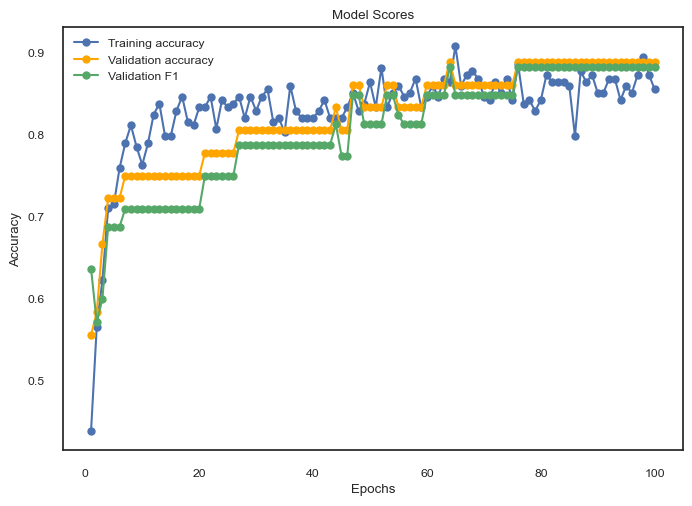

The best F1 score: 0.88235295


In [57]:
# Learning curve

# scores
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
F1_score = history.history['val_f1_score']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, acc, 'bo-', label='Training accuracy')
plt.plot(epochs, val_acc, 'o-', color='orange', label='Validation accuracy')
plt.plot(epochs, F1_score, 'go-', label='Validation F1')
plt.title('Model Scores')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# the best score
print('The best F1 score:', np.max(F1_score))

In [58]:
model.evaluate(test_ds)

4/4 [==============================] - 0s 18ms/step - loss: 0.4718 - accuracy: 0.8750 - f1_score: 0.8333


[0.47184666991233826, 0.875, array([0.8333333], dtype=float32)]

> **Predictions**

In [59]:
y_true = []
#y_pred_probs = []

for x, y_true_batch in test_ds:
    y_true.extend(y_true_batch.numpy().flatten())
#     y_pred_batch = model.predict(x)
#     y_pred_probs.extend(y_pred_batch.flatten())

In [60]:
predictions = pd.DataFrame({'pred_percent': model.predict(test_ds).reshape(-1)})
predictions['pred_round'] = np.round(model.predict(test_ds)).astype(int)
predictions['y_true_val'] = y_true
predictions['prediction'] = 'Healthy'
predictions['prediction'] = np.where(predictions['pred_round'] > 0, '_Disease_', 'Healthy')
predictions['y_true'] = ['_Disease_' if val>0 else 'Healthy' for val in y_true]

preds = predictions['pred_round']

def highlight_wrong_predictions(data: pd.DataFrame):
    #print(data.name)
    if data.y_true != data.prediction:
        return['background-color: pink']*5
    elif data.name % 2 == 0:
        return['background-color: white']*5
    else:
        return['background-color: whitesmoke']*5
    
display(predictions.style.apply(highlight_wrong_predictions, axis = 1))

4/4 [==============================] - 0s 4ms/step


,pred_percent,pred_round,y_true_val,prediction,y_true
0,0.008084,0,0,Healthy,Healthy
1,0.879620,1,1,_Disease_,_Disease_
2,0.000949,0,0,Healthy,Healthy
3,0.167514,0,0,Healthy,Healthy
4,0.019050,0,0,Healthy,Healthy
5,0.990549,1,1,_Disease_,_Disease_
6,0.008308,0,0,Healthy,Healthy
7,0.067242,0,0,Healthy,Healthy
8,0.991359,1,0,_Disease_,Healthy
9,0.996886,1,1,_Disease_,_Disease_


> **Final Scores**

In [61]:
from sklearn.metrics import classification_report

print(classification_report(y_true, preds))

              precision    recall  f1-score   support

           0       0.84      0.96      0.90        28
           1       0.94      0.75      0.83        20

    accuracy                           0.88        48
   macro avg       0.89      0.86      0.87        48
weighted avg       0.88      0.88      0.87        48



> **Confusion matrix**

In [62]:
import itertools
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    thresh = cm.max() / 1.1
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, cm[i, j], horizontalalignment="center", color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

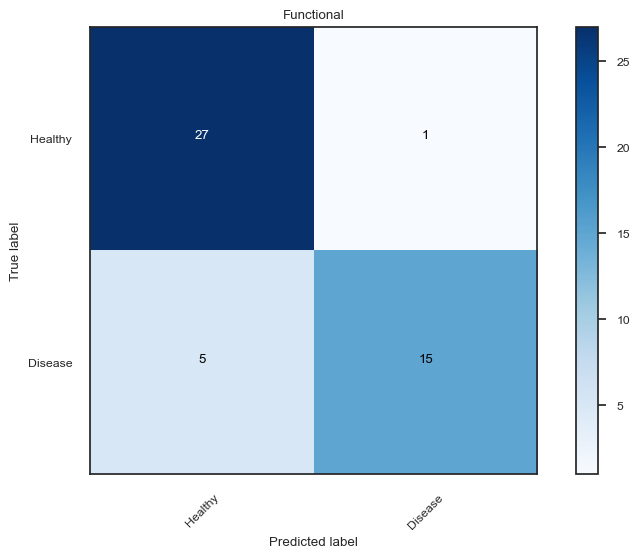

In [63]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, preds)
plot_confusion_matrix(cm, classes=['Healthy','Disease'], title=model.__class__.__name__)
plt.show()

# Saving model

In [64]:
# Save the model
model.save('Heart_Disease_Binary_Model')

INFO:tensorflow:Assets written to: Heart_Disease_Binary_Model\assets


INFO:tensorflow:Assets written to: Heart_Disease_Binary_Model\assets


In [65]:
# load model
loaded_model = tf.keras.models.load_model('Heart_Disease_Binary_Model')

In [66]:
# test loaded model
loaded_model.predict(test_ds)

4/4 [==============================] - 0s 5ms/step


array([[8.0835875e-03],
       [8.7962019e-01],
       [9.4873249e-04],
       [1.6751376e-01],
       [1.9049825e-02],
       [9.9054897e-01],
       [8.3082868e-03],
       [6.7242354e-02],
       [9.9135947e-01],
       [9.9688643e-01],
       [8.6518359e-01],
       [9.3540841e-01],
       [9.3466900e-03],
       [5.6798749e-02],
       [3.2492112e-03],
       [7.5149401e-03],
       [9.5794803e-01],
       [9.0309751e-01],
       [5.4640174e-03],
       [9.5944476e-01],
       [1.0727819e-03],
       [9.4294703e-01],
       [8.4003052e-03],
       [2.6271057e-01],
       [2.5267133e-01],
       [2.4511838e-01],
       [3.1404313e-01],
       [9.9720532e-01],
       [4.0921159e-03],
       [6.5389577e-05],
       [2.4951884e-01],
       [1.6814811e-03],
       [2.6642756e-05],
       [4.3682423e-01],
       [3.7083082e-02],
       [9.3367803e-01],
       [6.0356531e-02],
       [1.4711048e-01],
       [9.9506396e-01],
       [2.0661253e-01],
       [9.3654804e-03],
       [9.993162